# Incisos del 4 al 7.

### Importación de librerías.

In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

### Importación de datos.

In [86]:
df = pd.read_csv('datos_limpios.csv')
df.head(2)

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,room_type_Hotel room,room_type_Private room,room_type_Shared room,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,97.0,2,...,0,0,0,0,1,0,0,0,0,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,160.0,3,...,0,0,0,0,1,0,0,0,0,0


### Estadísticas del objetivo.

In [87]:
df['price'].describe()

count    73549.000000
mean       769.542958
std       4326.270197
min          8.000000
25%        120.000000
50%        194.000000
75%        330.000000
max      50123.000000
Name: price, dtype: float64

### Manejo de NaN

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73549 entries, 0 to 164211
Data columns (total 67 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_listings_count                           73549 non-null  float64
 1   host_total_listings_count                     73549 non-null  float64
 2   latitude                                      73549 non-null  float64
 3   longitude                                     73549 non-null  float64
 4   accommodates                                  73549 non-null  int64  
 5   bathrooms                                     73549 non-null  float64
 6   bedrooms                                      73549 non-null  float64
 7   beds                                          73549 non-null  float64
 8   price                                         73549 non-null  float64
 9   minimum_nights                                73549 non-null  int

### Se reemplazará los NaN por las medianas.

In [89]:
df = df.fillna(df.median(numeric_only=True))

Las categorías se harán a partir de los cuartiles. Aquellas que estén debajo del cuartil 1 se denominarán 'Económicas', las que estén entre el primer y el tercer cuartil se denominarán 'Intermedia' y el resto 'Cara'.

### Se crea la categoría y se elimina la variable price. (Inciso 6)

In [90]:
categoria = []
for x in df['price']:
    if x <= 120:
        categoria.append('Económica')
    elif x < 330:
        categoria.append('Intermedia')
    else:
        categoria.append('Cara')
df = df.drop(columns=['price'])

### Separación de datos

In [91]:
X_train, X_test, y_train, y_test = train_test_split(df, categoria, test_size=0.2, random_state=0, stratify=categoria)

### Modelo. (Inciso 4)

In [92]:
modelo = modelo_nb = GaussianNB(var_smoothing=1e-20)
modelo.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-20


### Eficiencia en el conjunto de prueba. (Inciso 5)

In [93]:
y_pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Exactitud del modelo:", accuracy)

Exactitud del modelo: 0.38885112168592795


### Errores del modelo. (Inciso 6)

<Figure size 800x600 with 0 Axes>

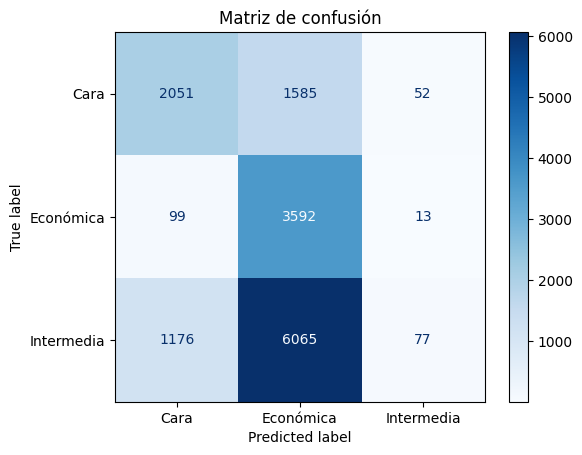

In [94]:
class_names = [str(c) for c in modelo.classes_]
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.show()

### ¿Puede estar sobreajustado? (Inciso 7)

In [95]:
y_pred_train = modelo.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
print("Exactitud del modelo:", accuracy_train)

Exactitud del modelo: 0.39336154591342476


No está sobreajustado, ya que el accuracy es similar entre el conunto de prueba y entrenamiento. Posiblemente el modelo no es útil para pronosticar estos datos.

### Conclusiones

El algoritmo etiqueta muy mal las casas "Intermedia", colocando correctamente el 1.1% de las etiquetas, siendo mucho peor que el azar.

El algoritmo etiqueta bien las casas "Económica", colocando correctamente el 97.0% de las etiquetas, esto puede deberse a que el algoritmo le da la mayor prioridad a esta etiqueta.  

El algoritmo lo hace muy mal con las casas "Cara", colocando correctamente el 55.6% de las etiquetas, siendo a penas mejor que el azar.

Por estas razones se considera que el modelo entrenado no es capaz de realizar una correcta categorización de las casas.
